In [4]:
import pandas as pd 
import seaborn as sns 

#chargement des data-set
data1=pd.read_csv('passages_1_heures_complet.csv')
data2=pd.read_csv('passages_2_heures_complet.csv')
data3=pd.read_csv('passages_3_heures_complet.csv')
data4=pd.read_csv('passages_2_minutes_complet.csv')
data5=pd.read_csv('passages_5_heures_complet.csv')
data6=pd.read_csv('passages_6_heures_complet.csv')
data7=pd.read_csv('rerA_v1_data.csv')
data8=pd.read_csv('rerA_v2_data.csv')
data9=pd.read_csv('rerA_v2_data.csv')

/tmp/ipykernel_10557/1449913.py:5: DtypeWarning: Columns (0: call_ArrivalProximityText_value, 1: vehicle_EstimatedCalls_EstimatedCall_0_ArrivalPlatformName_value, 2: vehicle_EstimatedCalls_EstimatedCall_0_DeparturePlatformName_value, 3: vehicle_EstimatedCalls_EstimatedCall_10_ArrivalPlatformName_value, 4: vehicle_EstimatedCalls_EstimatedCall_10_DeparturePlatformName_value, 5: vehicle_EstimatedCalls_EstimatedCall_11_ArrivalPlatformName_value, 6: vehicle_EstimatedCalls_EstimatedCall_11_DeparturePlatformName_value, 7: vehicle_EstimatedCalls_EstimatedCall_12_ArrivalPlatformName_value, 8: vehicle_EstimatedCalls_EstimatedCall_12_DeparturePlatformName_value, 9: vehicle_EstimatedCalls_EstimatedCall_13_ArrivalPlatformName_value, 10: vehicle_EstimatedCalls_EstimatedCall_13_DeparturePlatformName_value, 11: vehicle_EstimatedCalls_EstimatedCall_14_ArrivalPlatformName_value, 12: vehicle_EstimatedCalls_EstimatedCall_14_DeparturePlatformName_value, 13: vehicle_EstimatedCalls_EstimatedCall_15_ArrivalPl

In [6]:
#chargement des données 
df1=pd.DataFrame(data1)
df2=pd.DataFrame(data2)
df3=pd.DataFrame(data3)
df4=pd.DataFrame(data4)
df5=pd.DataFrame(data5)
df6=pd.DataFrame(data6)

In [7]:
#chargement des données 
df7=pd.DataFrame(data7)
df8=pd.DataFrame(data8)
df9=pd.DataFrame(data9)

In [8]:
dataset_final = pd.concat(
    [df1, df2, df3, df4, df5, df6,df7,df8,df9],
    ignore_index=True
)

In [9]:
data1.head()

,call_AimedArrivalTime,call_AimedDepartureTime,call_ArrivalPlatformName_value,call_ArrivalProximityText_value,call_ArrivalStatus,call_ArrivalStopAssignment_ExpectedQuayRef_value,call_DeparturePlatformName_value,call_DepartureStatus,call_DepartureStopAssignment_ExpectedQuayRef_value,call_DestinationDisplay_0_value,...,vehicle_EstimatedCalls_EstimatedCall_22_ArrivalProximityText_value,vehicle_EstimatedCalls_EstimatedCall_7_ArrivalProximityText_value,vehicle_EstimatedCalls_EstimatedCall_18_ArrivalProximityText_value,vehicle_EstimatedCalls_EstimatedCall_11_ArrivalProximityText_value,vehicle_EstimatedCalls_EstimatedCall_14_ArrivalProximityText_value,vehicle_EstimatedCalls_EstimatedCall_13_ArrivalProximityText_value,vehicle_EstimatedCalls_EstimatedCall_10_ArrivalProximityText_value,vehicle_EstimatedCalls_EstimatedCall_21_ArrivalProximityText_value,vehicle_EstimatedCalls_EstimatedCall_19_ArrivalProximityText_value,vehicle_EstimatedCalls_EstimatedCall_9_ArrivalProximityText_value
0,2026-03-20T17:26:34.000Z,2026-03-20T17:27:04.000Z,1,NaN,ON_TIME,STIF:StopPoint:Q:473930:,1,ON_TIME,STIF:StopPoint:Q:473930:,Torcy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-03-20T16:56:31.000Z,2026-03-20T16:57:26.000Z,1A,NaN,ON_TIME,STIF:StopPoint:Q:473993:,1A,ON_TIME,STIF:StopPoint:Q:473993:,Torcy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-03-20T17:13:50.000Z,2026-03-20T17:14:25.000Z,1,NaN,ON_TIME,STIF:StopPoint:Q:474042:,1,ON_TIME,STIF:StopPoint:Q:474042:,Torcy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-03-20T17:10:46.000Z,2026-03-20T17:11:41.000Z,1,NaN,ON_TIME,STIF:StopPoint:Q:474001:,1,ON_TIME,STIF:StopPoint:Q:474001:,Torcy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-03-20T17:06:23.000Z,2026-03-20T17:06:58.000Z,1,NaN,ON_TIME,STIF:StopPoint:Q:474000:,1,ON_TIME,STIF:StopPoint:Q:474000:,Torcy,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Train choisi : SNCF_MAGENTA_PRD:VehicleJourney::38dff808-6ec0-44fe-9cc2-cdad514d0dce:LOC
Arrêt choisi : STIF:StopArea:SP:43152:


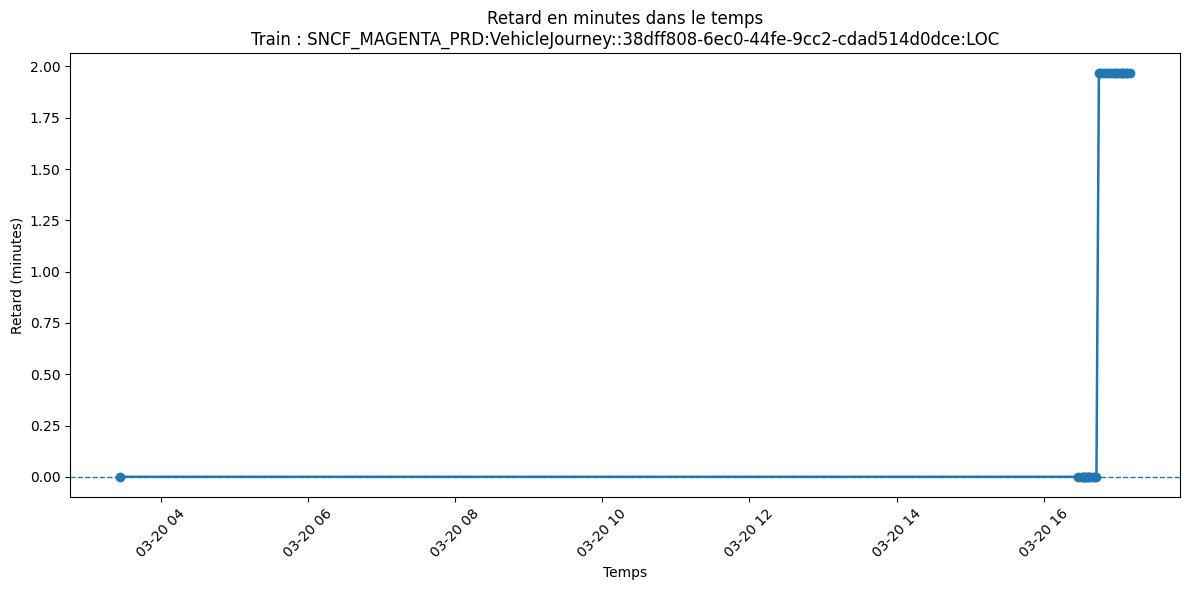

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 1) CHARGER LE FICHIER
# =========================
df = dataset_final

# =========================
# 2) COLONNES A UTILISER
# =========================
train_col = "vehicle_DatedVehicleJourneyRef_value"
time_col = "vehicle_RecordedAtTime"      # ou "date_requete"
expected_col = "call_ExpectedArrivalTime"
aimed_col = "call_AimedArrivalTime"
stop_col = "call_StopPointRef_value"     # utile pour filtrer un arrêt précis

# =========================
# 3) CONVERSION EN DATETIME
# =========================
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[expected_col] = pd.to_datetime(df[expected_col], errors="coerce")
df[aimed_col] = pd.to_datetime(df[aimed_col], errors="coerce")

# =========================
# 4) NETTOYAGE
# =========================
df = df.dropna(subset=[train_col, time_col, expected_col, aimed_col]).copy()

# =========================
# 5) CALCUL DU RETARD EN MINUTES
# =========================
df["retard_minutes"] = (df[expected_col] - df[aimed_col]).dt.total_seconds() / 60

# =========================
# 6) ARRONDIR LE TEMPS A LA MINUTE
#    (important car mesures toutes les 10 secondes)
# =========================
df["minute"] = df[time_col].dt.floor("min")

# =========================================================
# 7) DIAGRAMME PRINCIPAL :
#    GRAPHE EN LIGNE DU RETARD POUR UN TRAIN
# =========================================================

# ---- choisir un train
train_id = df[train_col].dropna().unique()[0]
# tu peux remplacer par un identifiant précis, par exemple :
# train_id = "SNCF_MAGENTA_PRD:VehicleJourney::38dff808-6ec0-44fe-9cc2-cdad514d0dce:LOC"

df_train = df[df[train_col] == train_id].copy()

# Option conseillée : si un train a plusieurs arrêts, prendre un arrêt précis
if stop_col in df_train.columns:
    stops = df_train[stop_col].dropna().unique()
    if len(stops) > 0:
        chosen_stop = stops[0]
        df_train = df_train[df_train[stop_col] == chosen_stop].copy()
        print("Train choisi :", train_id)
        print("Arrêt choisi :", chosen_stop)

# Agrégation par minute pour lisser
df_train_line = (
    df_train.groupby("minute", as_index=False)["retard_minutes"]
    .median()
    .sort_values("minute")
)

plt.figure(figsize=(12, 6))
plt.plot(df_train_line["minute"], df_train_line["retard_minutes"], marker="o", linewidth=1.8)
plt.axhline(0, linestyle="--", linewidth=1)

plt.title(f"Retard en minutes dans le temps\nTrain : {train_id}")
plt.xlabel("Temps")
plt.ylabel("Retard (minutes)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

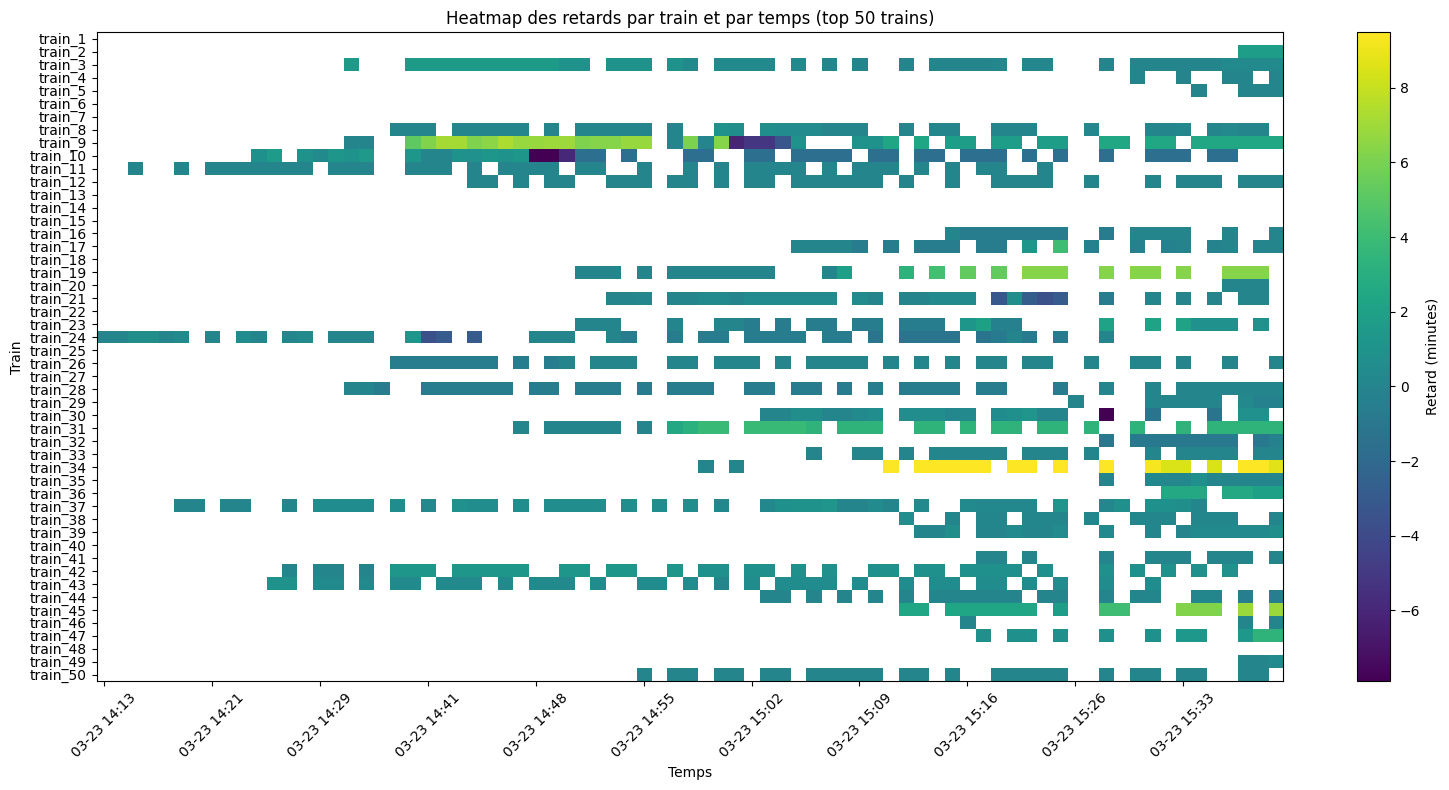

In [36]:
# les plus présents dans les données
top_n = 50

df_clean = df[(df["retard_minutes"] >= -8) & (df["retard_minutes"] <= 30)].copy()

top_trains = df_clean[train_col].value_counts().head(top_n).index
df_heat = df_clean[df_clean[train_col].isin(top_trains)].copy()

# Agréger par train et minute
heat_data = (
    df_heat.groupby([train_col, "minute"])["retard_minutes"]
    .median()
    .reset_index()
)

# Tableau croisé pour la heatmap
pivot = heat_data.pivot(index=train_col, columns="minute", values="retard_minutes")

# Trier les colonnes temporelles
pivot = pivot.sort_index(axis=1)

# Filtrer uniquement le 23/03 entre 14:00 et 16:00 en UTC
pivot = pivot.loc[:, 
    (pivot.columns >= pd.Timestamp("2026-03-23 14:00", tz="UTC")) &
    (pivot.columns <= pd.Timestamp("2026-03-23 16:00", tz="UTC"))
]
# Remplacer les noms longs des trains par train_1, train_2, ...
mapping = {train: f"train_{i+1}" for i, train in enumerate(pivot.index)}
pivot.index = pivot.index.map(mapping)
# Matrice pour affichage
matrix = pivot.to_numpy()

plt.figure(figsize=(16, 8))
img = plt.imshow(
    matrix,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(img, label="Retard (minutes)")
plt.title(f"Heatmap des retards par train et par temps (top {top_n} trains)")
plt.xlabel("Temps")
plt.ylabel("Train")

# ticks X
x_positions = np.arange(len(pivot.columns))
step = max(1, len(x_positions) // 10)

plt.xticks(
    x_positions[::step],
    [pd.to_datetime(t).strftime("%m-%d %H:%M") for t in pivot.columns[::step]],
    rotation=45
)

# ticks Y
y_positions = np.arange(len(pivot.index))
plt.yticks(y_positions, pivot.index)

plt.tight_layout()
plt.show()

In [23]:
len(df[df["retard_minutes"] < -10][[
    "vehicle_DatedVehicleJourneyRef_value",
    "vehicle_RecordedAtTime",
    "call_StopPointRef_value",
    "call_ExpectedArrivalTime",
    "call_AimedArrivalTime",
    "retard_minutes"
]])

14614

In [30]:
df['vehicle_PublishedLineName_0_value'].unique()

<StringArray>
['A']
Length: 1, dtype: str

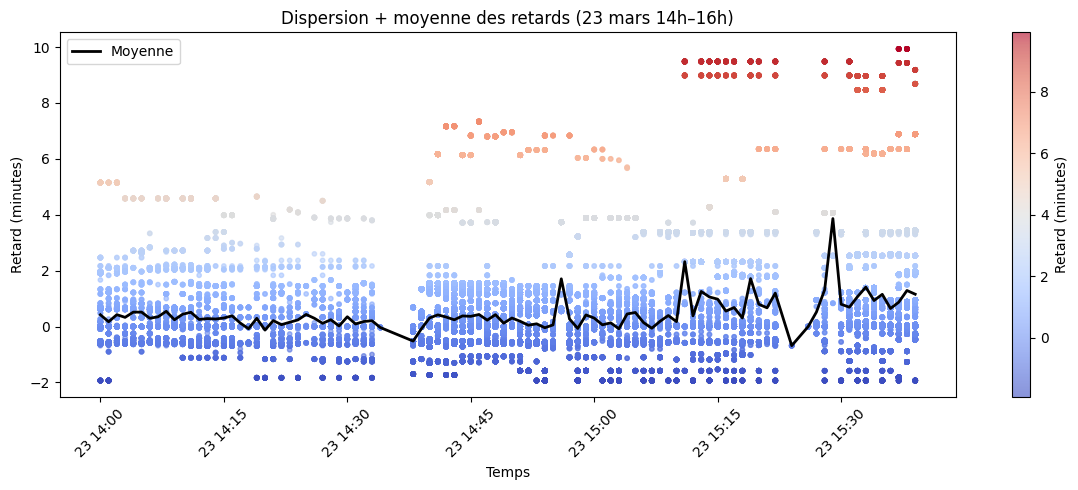

In [48]:
df_clean = df[(df["retard_minutes"] >= -2) & (df["retard_minutes"] <= 30)]
df_scatter = df_clean[
    (df_clean["minute"] >= pd.Timestamp("2026-03-23 14:00", tz="UTC")) &
    (df_clean["minute"] <= pd.Timestamp("2026-03-23 16:00", tz="UTC"))
]

plt.figure(figsize=(12,5))

# scatter avec couleur selon le retard
sc = plt.scatter(
    df_scatter["minute"],
    df_scatter["retard_minutes"],
    c=df_scatter["retard_minutes"],   # couleur = retard
    cmap="coolwarm",                  # bleu → négatif, rouge → positif
    s=10,
    alpha=0.6
)

# moyenne (ligne de tendance)
mean_retard = df_scatter.groupby("minute")["retard_minutes"].mean()

plt.plot(
    mean_retard.index,
    mean_retard.values,
    color="black",     # bien visible
    linewidth=2,
    label="Moyenne"
)

# colorbar pour interprétation
plt.colorbar(sc, label="Retard (minutes)")

plt.title("Dispersion + moyenne des retards (23 mars 14h–16h)")
plt.xlabel("Temps")
plt.ylabel("Retard (minutes)")
plt.xticks(rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

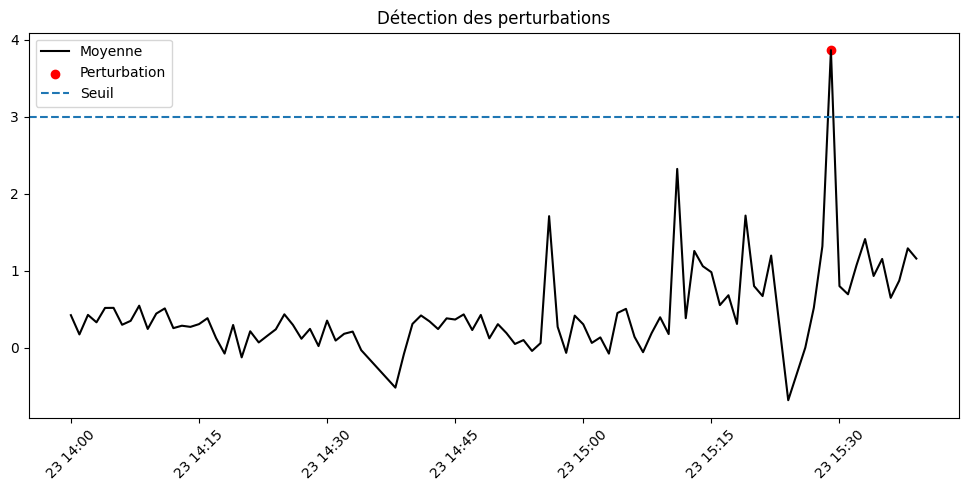

In [51]:
seuil = 3  # minutes

mean_retard = df_scatter.groupby("minute")["retard_minutes"].mean()

perturbation = mean_retard > seuil

plt.figure(figsize=(12,5))

plt.plot(mean_retard.index, mean_retard.values, label="Moyenne", color="black")

plt.scatter(
    mean_retard.index[perturbation],
    mean_retard[perturbation],
    color="red",
    label="Perturbation"
)

plt.axhline(y=seuil, linestyle="--", label="Seuil")

plt.legend()
plt.title("Détection des perturbations")
plt.xticks(rotation=45)
plt.show()

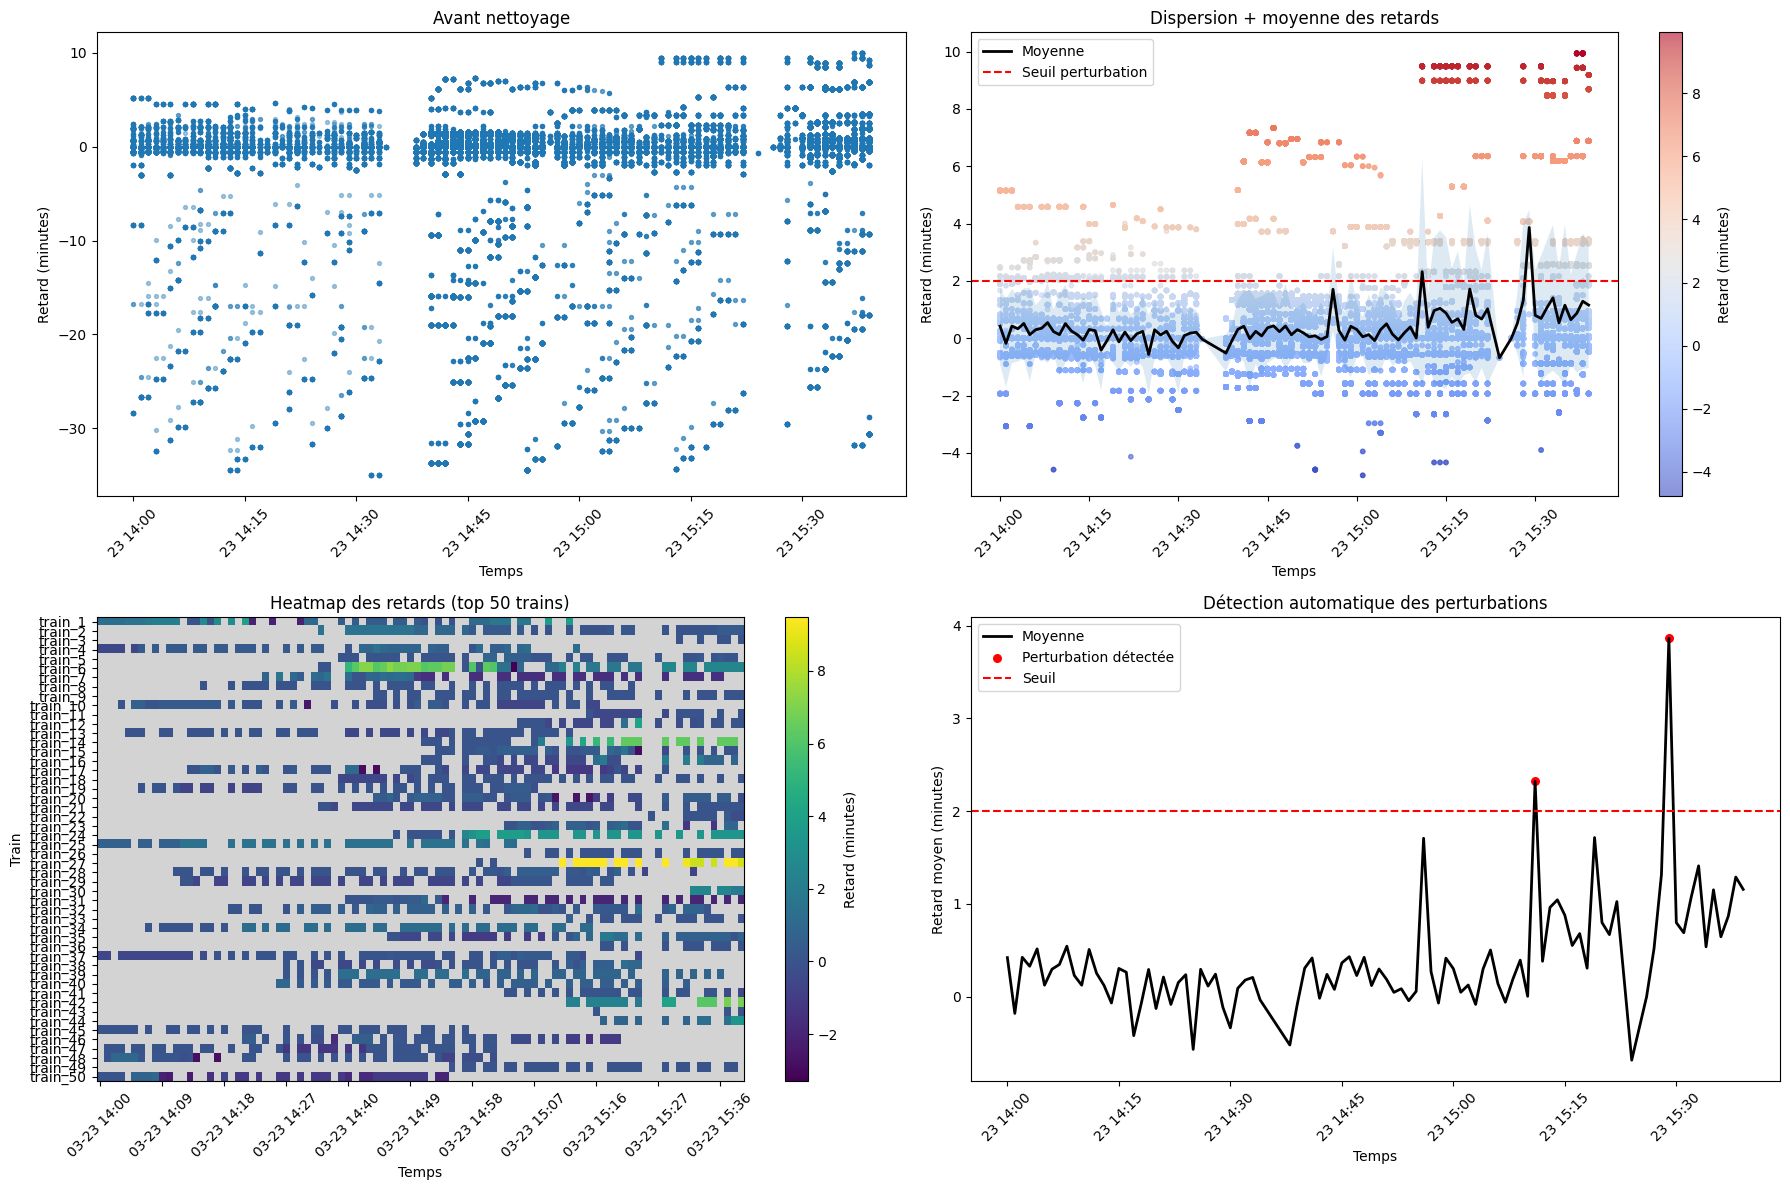


--- Résumé global ---
Nombre de lignes avant nettoyage : 1340364
Nombre de lignes après nettoyage : 1320302
Nombre de lignes dans la fenêtre : 117769

--- Minutes détectées comme perturbées ---
minute
2026-03-23 15:11:00+00:00    2.321184
2026-03-23 15:29:00+00:00    3.862928
Name: retard_minutes, dtype: float64

--- Top 10 trains les plus perturbés (retard moyen) ---
vehicle_DatedVehicleJourneyRef_value
SNCF_MAGENTA_PRD:VehicleJourney::97b92a9e-a45d-43d7-b846-9cdb9f1fe45d:LOC    5.851424
SNCF_MAGENTA_PRD:VehicleJourney::e769c929-ad24-4a46-91b8-d1e90170395a:LOC    4.588654
SNCF_MAGENTA_PRD:VehicleJourney::11ccb571-a375-4b31-895b-1457a3613997:LOC    4.232547
SNCF_MAGENTA_PRD:VehicleJourney::1cdd7de0-7e3e-46f3-93a3-590001769869:LOC    3.644273
SNCF_MAGENTA_PRD:VehicleJourney::8601b7d0-6857-40d0-80ac-51c85d9c5733:LOC    2.633333
SNCF_MAGENTA_PRD:VehicleJourney::0bad7f51-b073-4bee-8e20-7191ef91b8c1:LOC    2.562623
SNCF_MAGENTA_PRD:VehicleJourney::ab643f42-029f-4956-8d4f-bc5657cda804:LOC  

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) PARAMETRES
# =========================
top_n = 50
train_col = "vehicle_DatedVehicleJourneyRef_value"
time_col = "vehicle_RecordedAtTime"   # ou "date_requete" si besoin
expected_col = "call_ExpectedArrivalTime"
aimed_col = "call_AimedArrivalTime"

start_time = "2026-03-23 14:00"
end_time   = "2026-03-23 16:00"
timezone   = "UTC"

# =========================
# 2) PREPARATION DES DONNEES
# =========================
df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)
df[expected_col] = pd.to_datetime(df[expected_col], errors="coerce", utc=True)
df[aimed_col] = pd.to_datetime(df[aimed_col], errors="coerce", utc=True)

df = df.dropna(subset=[train_col, time_col, expected_col, aimed_col]).copy()

# retard en minutes
df["retard_minutes"] = (df[expected_col] - df[aimed_col]).dt.total_seconds() / 60

# temps arrondi à la minute
df["minute"] = df[time_col].dt.floor("min")

# =========================
# 3) NETTOYAGE DES INCOHERENCES
# =========================
df_clean = df[(df["retard_minutes"] >= -5) & (df["retard_minutes"] <= 30)].copy()

# =========================
# 4) FILTRE TEMPOREL
# =========================
start_ts = pd.Timestamp(start_time, tz=timezone)
end_ts = pd.Timestamp(end_time, tz=timezone)

df_scatter = df_clean[
    (df_clean["minute"] >= start_ts) &
    (df_clean["minute"] <= end_ts)
].copy()

# =========================
# 5) HEATMAP TOP N TRAINS
# =========================
top_trains = df_scatter[train_col].value_counts().head(top_n).index
df_heat = df_scatter[df_scatter[train_col].isin(top_trains)].copy()

heat_data = (
    df_heat.groupby([train_col, "minute"])["retard_minutes"]
    .median()
    .reset_index()
)

pivot = heat_data.pivot(index=train_col, columns="minute", values="retard_minutes")
pivot = pivot.sort_index(axis=1)

mapping = {train: f"train_{i+1}" for i, train in enumerate(pivot.index)}
pivot.index = pivot.index.map(mapping)

# =========================
# 6) COURBE MOYENNE + DETECTION
# =========================
mean_retard = df_scatter.groupby("minute")["retard_minutes"].mean()
std_retard = df_scatter.groupby("minute")["retard_minutes"].std()

seuil = 2
perturbation = mean_retard > seuil

# =========================
# 7) FIGURE COMPLETE
# =========================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# -------- (A) Avant nettoyage
axes[0, 0].scatter(
    df[
        (df["minute"] >= start_ts) &
        (df["minute"] <= end_ts)
    ]["minute"],
    df[
        (df["minute"] >= start_ts) &
        (df["minute"] <= end_ts)
    ]["retard_minutes"],
    s=8,
    alpha=0.4
)
axes[0, 0].set_title("Avant nettoyage")
axes[0, 0].set_xlabel("Temps")
axes[0, 0].set_ylabel("Retard (minutes)")
axes[0, 0].tick_params(axis="x", rotation=45)

# -------- (B) Après nettoyage : dispersion + moyenne
sc = axes[0, 1].scatter(
    df_scatter["minute"],
    df_scatter["retard_minutes"],
    c=df_scatter["retard_minutes"],
    cmap="coolwarm",
    s=10,
    alpha=0.6
)

axes[0, 1].plot(
    mean_retard.index,
    mean_retard.values,
    color="black",
    linewidth=2,
    label="Moyenne"
)

axes[0, 1].fill_between(
    mean_retard.index,
    mean_retard - std_retard,
    mean_retard + std_retard,
    alpha=0.15
)

axes[0, 1].axhline(y=seuil, color="red", linestyle="--", linewidth=1.5, label="Seuil perturbation")
axes[0, 1].set_title("Dispersion + moyenne des retards")
axes[0, 1].set_xlabel("Temps")
axes[0, 1].set_ylabel("Retard (minutes)")
axes[0, 1].legend()
axes[0, 1].tick_params(axis="x", rotation=45)

cbar1 = fig.colorbar(sc, ax=axes[0, 1])
cbar1.set_label("Retard (minutes)")

# -------- (C) Heatmap
if pivot.shape[1] > 0:
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="lightgray")

    img = axes[1, 0].imshow(
        pivot.to_numpy(),
        aspect="auto",
        interpolation="nearest",
        cmap=cmap
    )

    axes[1, 0].set_title(f"Heatmap des retards (top {top_n} trains)")
    axes[1, 0].set_xlabel("Temps")
    axes[1, 0].set_ylabel("Train")

    x_positions = np.arange(len(pivot.columns))
    step = max(1, len(x_positions) // 10)

    axes[1, 0].set_xticks(x_positions[::step])
    axes[1, 0].set_xticklabels(
        [t.strftime("%m-%d %H:%M") for t in pivot.columns[::step]],
        rotation=45
    )

    y_positions = np.arange(len(pivot.index))
    axes[1, 0].set_yticks(y_positions)
    axes[1, 0].set_yticklabels(pivot.index)

    cbar2 = fig.colorbar(img, ax=axes[1, 0])
    cbar2.set_label("Retard (minutes)")
else:
    axes[1, 0].text(0.5, 0.5, "Aucune donnée pour la heatmap", ha="center", va="center")
    axes[1, 0].set_title(f"Heatmap des retards (top {top_n} trains)")
    axes[1, 0].set_axis_off()

# -------- (D) Détection automatique des perturbations
axes[1, 1].plot(mean_retard.index, mean_retard.values, color="black", linewidth=2, label="Moyenne")
axes[1, 1].scatter(
    mean_retard.index[perturbation],
    mean_retard[perturbation],
    color="red",
    s=30,
    label="Perturbation détectée"
)
axes[1, 1].axhline(y=seuil, color="red", linestyle="--", linewidth=1.5, label="Seuil")
axes[1, 1].set_title("Détection automatique des perturbations")
axes[1, 1].set_xlabel("Temps")
axes[1, 1].set_ylabel("Retard moyen (minutes)")
axes[1, 1].legend()
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# =========================
# 8) TABLEAUX RESUME
# =========================
print("\n--- Résumé global ---")
print("Nombre de lignes avant nettoyage :", len(df))
print("Nombre de lignes après nettoyage :", len(df_clean))
print("Nombre de lignes dans la fenêtre :", len(df_scatter))

print("\n--- Minutes détectées comme perturbées ---")
print(mean_retard[perturbation])

print("\n--- Top 10 trains les plus perturbés (retard moyen) ---")
top_perturb = (
    df_scatter.groupby(train_col)["retard_minutes"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
print(top_perturb)

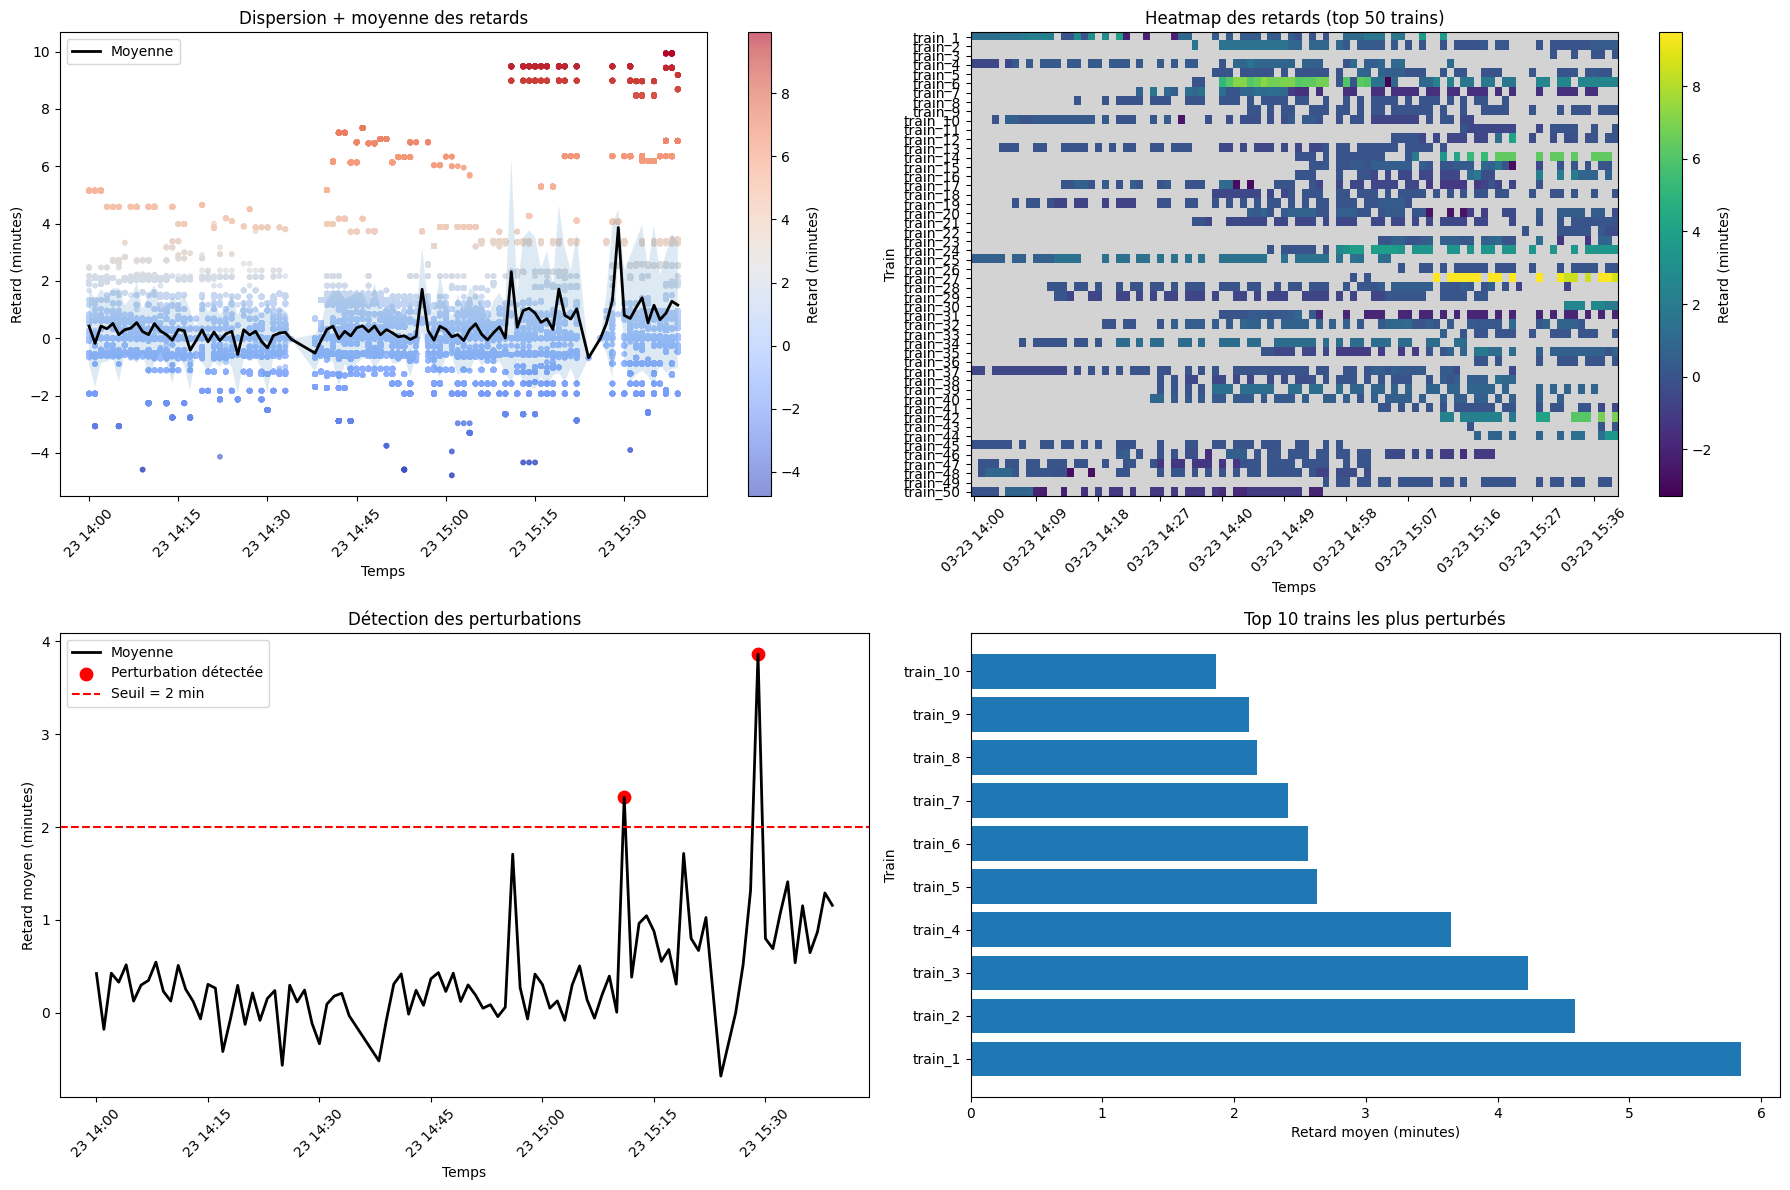


--- Résumé global ---
Nombre de lignes avant nettoyage : 1340364
Nombre de lignes après nettoyage : 1320302
Nombre de lignes dans la fenêtre : 117769

--- Minutes détectées comme perturbées ---
minute
2026-03-23 15:11:00+00:00    2.321184
2026-03-23 15:29:00+00:00    3.862928
Name: retard_minutes, dtype: float64

--- Top 10 trains les plus perturbés (retard moyen) ---
vehicle_DatedVehicleJourneyRef_value
SNCF_MAGENTA_PRD:VehicleJourney::97b92a9e-a45d-43d7-b846-9cdb9f1fe45d:LOC    5.851424
SNCF_MAGENTA_PRD:VehicleJourney::e769c929-ad24-4a46-91b8-d1e90170395a:LOC    4.588654
SNCF_MAGENTA_PRD:VehicleJourney::11ccb571-a375-4b31-895b-1457a3613997:LOC    4.232547
SNCF_MAGENTA_PRD:VehicleJourney::1cdd7de0-7e3e-46f3-93a3-590001769869:LOC    3.644273
SNCF_MAGENTA_PRD:VehicleJourney::8601b7d0-6857-40d0-80ac-51c85d9c5733:LOC    2.633333
SNCF_MAGENTA_PRD:VehicleJourney::0bad7f51-b073-4bee-8e20-7191ef91b8c1:LOC    2.562623
SNCF_MAGENTA_PRD:VehicleJourney::ab643f42-029f-4956-8d4f-bc5657cda804:LOC  

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1) PARAMETRES
# =========================
top_n = 50
train_col = "vehicle_DatedVehicleJourneyRef_value"
time_col = "vehicle_RecordedAtTime"   # ou "date_requete"
expected_col = "call_ExpectedArrivalTime"
aimed_col = "call_AimedArrivalTime"

start_time = "2026-03-23 14:00"
end_time   = "2026-03-23 16:00"
timezone   = "UTC"
seuil_perturbation = 2  # minutes

# =========================
# 2) PREPARATION DES DONNEES
# =========================
df[time_col] = pd.to_datetime(df[time_col], errors="coerce", utc=True)
df[expected_col] = pd.to_datetime(df[expected_col], errors="coerce", utc=True)
df[aimed_col] = pd.to_datetime(df[aimed_col], errors="coerce", utc=True)

df = df.dropna(subset=[train_col, time_col, expected_col, aimed_col]).copy()

# Calcul du retard en minutes
df["retard_minutes"] = (df[expected_col] - df[aimed_col]).dt.total_seconds() / 60

# Arrondi du temps à la minute
df["minute"] = df[time_col].dt.floor("min")

# =========================
# 3) NETTOYAGE
# =========================
df_clean = df[(df["retard_minutes"] >= -5) & (df["retard_minutes"] <= 30)].copy()

# =========================
# 4) FILTRE TEMPOREL
# =========================
start_ts = pd.Timestamp(start_time, tz=timezone)
end_ts = pd.Timestamp(end_time, tz=timezone)

df_window = df_clean[
    (df_clean["minute"] >= start_ts) &
    (df_clean["minute"] <= end_ts)
].copy()

# =========================
# 5) COURBE MOYENNE + DETECTION
# =========================
mean_retard = df_window.groupby("minute")["retard_minutes"].mean()
std_retard = df_window.groupby("minute")["retard_minutes"].std()
perturbation = mean_retard > seuil_perturbation

# =========================
# 6) HEATMAP TOP N TRAINS
# =========================
top_trains = df_window[train_col].value_counts().head(top_n).index
df_heat = df_window[df_window[train_col].isin(top_trains)].copy()

heat_data = (
    df_heat.groupby([train_col, "minute"])["retard_minutes"]
    .median()
    .reset_index()
)

pivot = heat_data.pivot(index=train_col, columns="minute", values="retard_minutes")
pivot = pivot.sort_index(axis=1)

mapping_heat = {train: f"train_{i+1}" for i, train in enumerate(pivot.index)}
pivot.index = pivot.index.map(mapping_heat)

# =========================
# 7) TOP 10 TRAINS LES PLUS PERTURBES
# =========================
top_perturb = (
    df_window.groupby(train_col)["retard_minutes"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_perturb_plot = top_perturb.copy()
top_perturb_plot.index = [f"train_{i+1}" for i in range(len(top_perturb_plot))]

# =========================
# 8) FIGURE COMPLETE
# =========================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# -------- (A) Dispersion + moyenne
sc = axes[0, 0].scatter(
    df_window["minute"],
    df_window["retard_minutes"],
    c=df_window["retard_minutes"],
    cmap="coolwarm",
    s=10,
    alpha=0.6
)

axes[0, 0].plot(
    mean_retard.index,
    mean_retard.values,
    color="black",
    linewidth=2,
    label="Moyenne"
)

axes[0, 0].fill_between(
    mean_retard.index,
    mean_retard - std_retard,
    mean_retard + std_retard,
    alpha=0.15
)

axes[0, 0].set_title("Dispersion + moyenne des retards")
axes[0, 0].set_xlabel("Temps")
axes[0, 0].set_ylabel("Retard (minutes)")
axes[0, 0].legend()
axes[0, 0].tick_params(axis="x", rotation=45)

cbar1 = fig.colorbar(sc, ax=axes[0, 0])
cbar1.set_label("Retard (minutes)")

# -------- (B) Heatmap
if pivot.shape[1] > 0:
    cmap = plt.cm.viridis.copy()
    cmap.set_bad(color="lightgray")

    img = axes[0, 1].imshow(
        pivot.to_numpy(),
        aspect="auto",
        interpolation="nearest",
        cmap=cmap
    )

    axes[0, 1].set_title(f"Heatmap des retards (top {top_n} trains)")
    axes[0, 1].set_xlabel("Temps")
    axes[0, 1].set_ylabel("Train")

    x_positions = np.arange(len(pivot.columns))
    step = max(1, len(x_positions) // 10)

    axes[0, 1].set_xticks(x_positions[::step])
    axes[0, 1].set_xticklabels(
        [t.strftime("%m-%d %H:%M") for t in pivot.columns[::step]],
        rotation=45
    )

    y_positions = np.arange(len(pivot.index))
    axes[0, 1].set_yticks(y_positions)
    axes[0, 1].set_yticklabels(pivot.index)

    cbar2 = fig.colorbar(img, ax=axes[0, 1])
    cbar2.set_label("Retard (minutes)")
else:
    axes[0, 1].text(0.5, 0.5, "Aucune donnée pour la heatmap", ha="center", va="center")
    axes[0, 1].set_axis_off()

# -------- (C) Détection automatique des perturbations
axes[1, 0].plot(
    mean_retard.index,
    mean_retard.values,
    color="black",
    linewidth=2,
    label="Moyenne"
)

axes[1, 0].scatter(
    mean_retard.index[perturbation],
    mean_retard[perturbation],
    color="red",
    s=80,
    label="Perturbation détectée"
)

axes[1, 0].axhline(
    y=seuil_perturbation,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Seuil = {seuil_perturbation} min"
)

axes[1, 0].set_title("Détection des perturbations")
axes[1, 0].set_xlabel("Temps")
axes[1, 0].set_ylabel("Retard moyen (minutes)")
axes[1, 0].legend()
axes[1, 0].tick_params(axis="x", rotation=45)

# -------- (D) Top 10 trains les plus perturbés
axes[1, 1].barh(top_perturb_plot.index, top_perturb_plot.values)
axes[1, 1].set_title("Top 10 trains les plus perturbés")
axes[1, 1].set_xlabel("Retard moyen (minutes)")
axes[1, 1].set_ylabel("Train")

plt.tight_layout()
plt.show()

# =========================
# 9) RESUME TEXTE
# =========================
print("\n--- Résumé global ---")
print("Nombre de lignes avant nettoyage :", len(df))
print("Nombre de lignes après nettoyage :", len(df_clean))
print("Nombre de lignes dans la fenêtre :", len(df_window))

print("\n--- Minutes détectées comme perturbées ---")
print(mean_retard[perturbation])

print("\n--- Top 10 trains les plus perturbés (retard moyen) ---")
print(top_perturb)

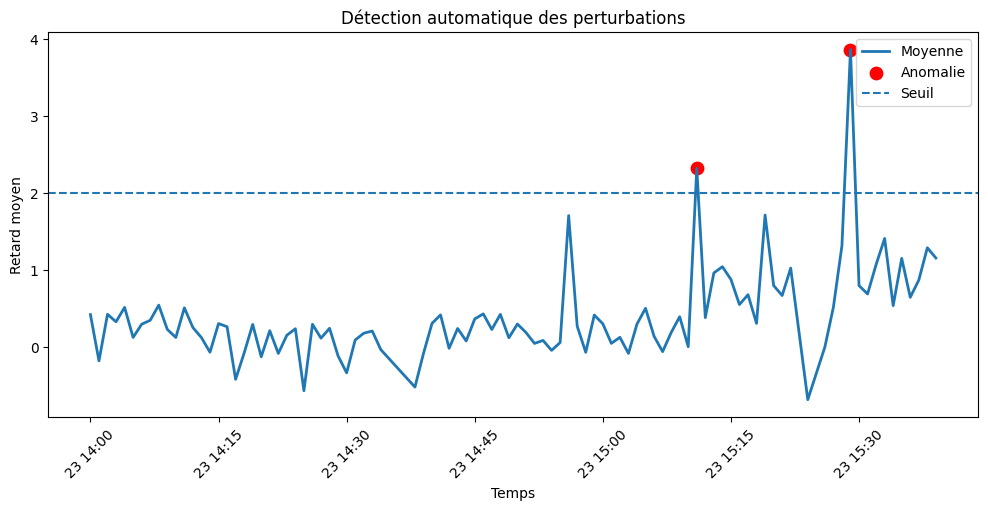

In [54]:
seuil = 2  # seuil perturbation (à ajuster)

plt.figure(figsize=(12,5))

# courbe moyenne
plt.plot(mean_retard.index, mean_retard.values, label="Moyenne", linewidth=2)

# anomalies
anomalies = mean_retard > seuil
plt.scatter(
    mean_retard.index[anomalies],
    mean_retard[anomalies],
    color="red",
    s=80,
    label="Anomalie"
)

# seuil
plt.axhline(y=seuil, linestyle="--", label="Seuil")

plt.title("Détection automatique des perturbations")
plt.xlabel("Temps")
plt.ylabel("Retard moyen")
plt.legend()
plt.xticks(rotation=45)
plt.show()

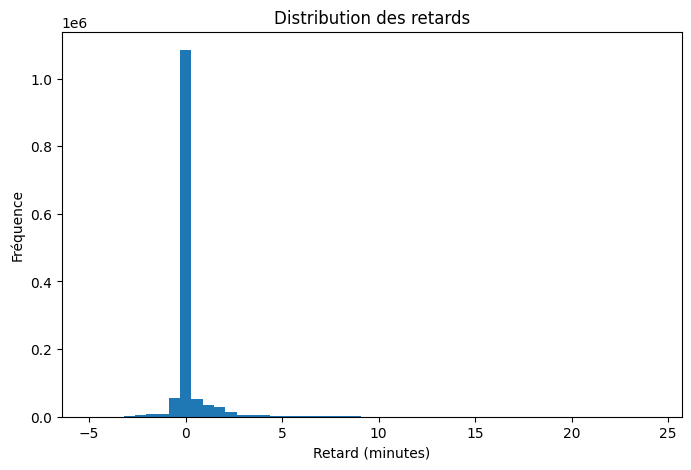

In [55]:
plt.figure(figsize=(8,5))

plt.hist(df_clean["retard_minutes"], bins=50)

plt.title("Distribution des retards")
plt.xlabel("Retard (minutes)")
plt.ylabel("Fréquence")

plt.show()

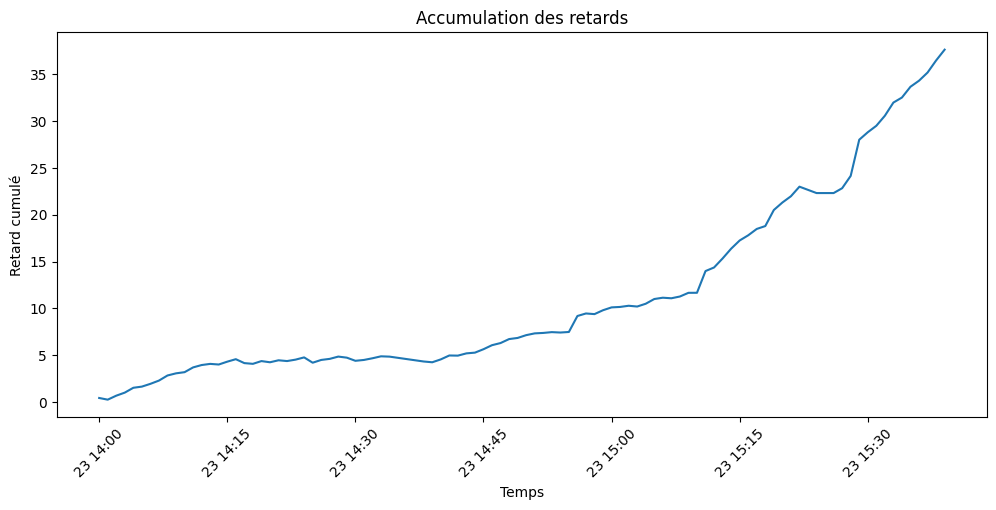

In [56]:
cumul = mean_retard.cumsum()

plt.figure(figsize=(12,5))
plt.plot(cumul.index, cumul.values)

plt.title("Accumulation des retards")
plt.xlabel("Temps")
plt.ylabel("Retard cumulé")

plt.xticks(rotation=45)
plt.show()

Mois présents : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
        JOUR  MOIS  NB_VALID
0 2024-04-01     4      1235
1 2024-04-01     4       727
2 2024-04-01     4      2667
3 2024-04-01     4      5549
4 2024-04-01     4       124


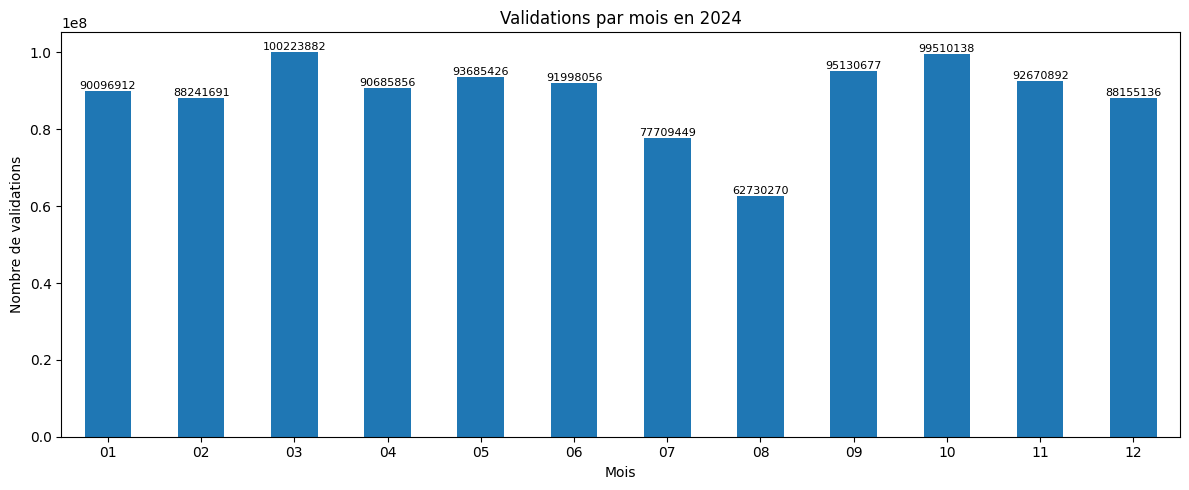

In [81]:
import pandas as pd
import glob
import matplotlib.pyplot as plt

files = glob.glob("2024_T*_NB_SURFACE.txt")

df_list = []

def parse_date_series(series):
    # Essai 1 : dates du type 01/10/24
    d1 = pd.to_datetime(series, format="%d/%m/%y", errors="coerce")
    # Essai 2 : dates du type 01/04/2024
    d2 = pd.to_datetime(series, format="%d/%m/%Y", errors="coerce")
    # On garde d1 si trouvé, sinon d2
    return d1.fillna(d2)

for file in files:
    df = pd.read_csv(
        file,
        sep="\t",
        encoding="cp1252",
        low_memory=False
    )

    df.columns = df.columns.str.strip()

    if "NB_VALD" in df.columns and "NB_VALID" not in df.columns:
        df = df.rename(columns={"NB_VALD": "NB_VALID"})

    df["JOUR"] = df["JOUR"].astype(str).str.strip()
    df["JOUR"] = parse_date_series(df["JOUR"])

    df["NB_VALID"] = pd.to_numeric(df["NB_VALID"], errors="coerce")

    df_list.append(df)

df_affluence = pd.concat(df_list, ignore_index=True, sort=False)
df_affluence["MOIS"] = df_affluence["JOUR"].dt.month

print("Mois présents :", sorted(df_affluence["MOIS"].dropna().unique()))
print(df_affluence[["JOUR", "MOIS", "NB_VALID"]].head())

evolution = df_affluence.groupby("MOIS")["NB_VALID"].sum()
evolution = evolution.reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(12, 5))
ax = evolution.plot(kind="bar")

ax.set_title("Validations par mois en 2024")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de validations")
ax.set_xticklabels([f"{i:02d}" for i in range(1, 13)], rotation=0)

for i, v in enumerate(evolution):
    ax.text(i, v, f"{int(v)}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

Colonnes disponibles :
['Geo Point', 'Geo Shape', 'OBJECTID_1', 'gares_id', 'nom_long', 'nom_so_gar', 'nom_su_gar', 'id_ref_ZdC', 'nom_ZdC', 'id_ref_ZdA', 'nom_ZdA', 'idrefliga', 'idrefligc', 'res_com', 'indice_lig', 'mode', 'tertrain', 'terrer', 'termetro', 'tertram', 'terval', 'exploitant', 'idf', 'principal', 'x', 'y', 'picto ligne', 'nom_iv']

===== RER =====
   ligne  nb_stations  couleur
0  RER A           46  #E3051C
1  RER B           47  #5291CE
2  RER C           75  #FFCC30
3  RER D           59  #008B5B
4  RER E           25  #A0006E

===== Transilien =====
  ligne  nb_stations  couleur
5     H           50  #8D5E2A
6     J           52  #D4A017
7     K           10  #4B5320
8     L           64  #C9A3C9
9     N          109  #00A88F


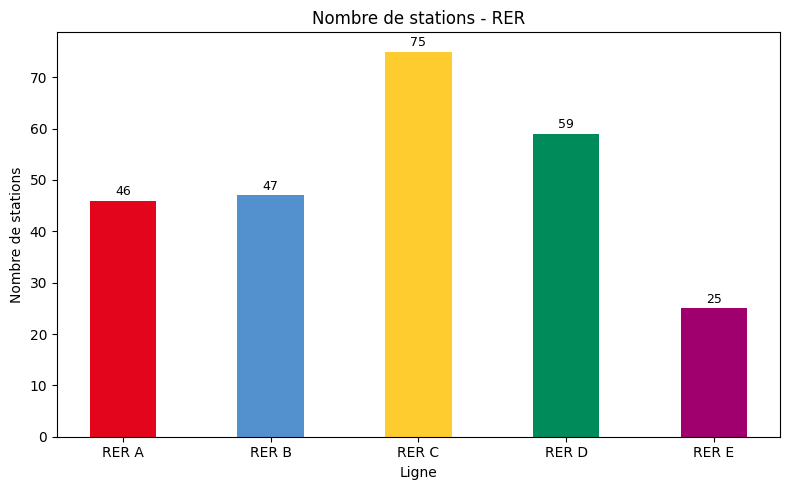

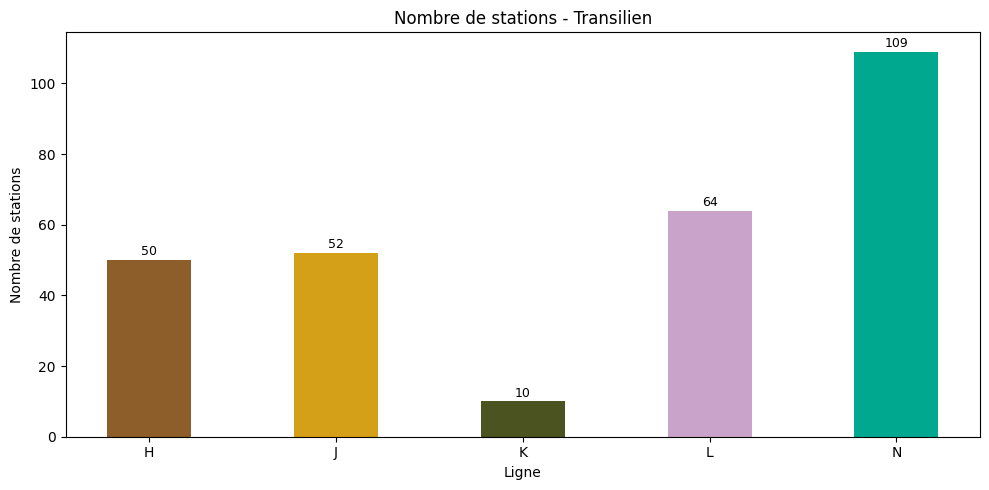

In [91]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Charger le fichier
# =========================
gares = pd.read_csv(
    "emplacement-des-gares-idf (1).csv",
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

# Nettoyage des noms de colonnes
gares.columns = gares.columns.str.strip()

# Vérification minimale
print("Colonnes disponibles :")
print(gares.columns.tolist())

# =========================
# 2. Nettoyer les colonnes utiles
# =========================
gares["mode"] = gares["mode"].astype(str).str.strip().str.upper()
gares["res_com"] = gares["res_com"].astype(str).str.strip().str.upper()
gares["gares_id"] = gares["gares_id"].astype(str).str.strip()

# On garde seulement RER et TRAIN
gares = gares[gares["mode"].isin(["RER", "TRAIN"])].copy()

# =========================
# 3. Normaliser les noms de lignes
# =========================
def normaliser_ligne(row):
    mode = row["mode"]
    val = row["res_com"]

    # Cas RER
    if mode == "RER":
        for lettre in ["A", "B", "C", "D", "E"]:
            if lettre in val:
                return f"RER {lettre}"

    # Cas Transilien
    if mode == "TRAIN":
        for lettre in ["H", "J", "K", "L", "N", "P", "R", "U", "V"]:
            if lettre in val:
                return lettre

    return None

gares["ligne"] = gares.apply(normaliser_ligne, axis=1)

# Supprimer les lignes non reconnues
gares = gares[gares["ligne"].notna()].copy()

# =========================
# 4. Couleurs officielles
# =========================
couleurs_lignes = {
    "RER A": "#E3051C",
    "RER B": "#5291CE",
    "RER C": "#FFCC30",
    "RER D": "#008B5B",
    "RER E": "#A0006E",
    "H": "#8D5E2A",
    "J": "#D4A017",
    "K": "#4B5320",
    "L": "#C9A3C9",
    "N": "#00A88F",
    "P": "#F28E00",
    "R": "#F4A6B8",
    "U": "#A50034",
    "V": "#6DA544"
}

# =========================
# 5. Compter les stations
# =========================
nb_stations = (
    gares.groupby(["mode", "ligne"])["gares_id"]
    .nunique()
    .reset_index(name="nb_stations")
)

nb_stations["couleur"] = nb_stations["ligne"].map(couleurs_lignes).fillna("#999999")

# =========================
# 6. Séparer RER et Transilien
# =========================
ordre_rer = ["RER A", "RER B", "RER C", "RER D", "RER E"]
ordre_transilien = ["H", "J", "K", "L", "N", "P", "R", "U", "V"]

df_rer = nb_stations[nb_stations["mode"] == "RER"].copy()
df_transilien = nb_stations[nb_stations["mode"] == "TRAIN"].copy()

df_rer["ligne"] = pd.Categorical(df_rer["ligne"], categories=ordre_rer, ordered=True)
df_rer = df_rer.sort_values("ligne")

df_transilien["ligne"] = pd.Categorical(df_transilien["ligne"], categories=ordre_transilien, ordered=True)
df_transilien = df_transilien.sort_values("ligne")

# =========================
# 7. Afficher les tableaux
# =========================
print("\n===== RER =====")
print(df_rer[["ligne", "nb_stations", "couleur"]])

print("\n===== Transilien =====")
print(df_transilien[["ligne", "nb_stations", "couleur"]])

# =========================
# 8. Graphique RER
# =========================
plt.figure(figsize=(8, 5))
bars = plt.bar(
    df_rer["ligne"].astype(str),
    df_rer["nb_stations"],
    color=df_rer["couleur"],
    width=0.45
)

plt.title("Nombre de stations - RER")
plt.xlabel("Ligne")
plt.ylabel("Nombre de stations")

for i, v in enumerate(df_rer["nb_stations"]):
    plt.text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# =========================
# 9. Graphique Transilien
# =========================
plt.figure(figsize=(10, 5))
bars = plt.bar(
    df_transilien["ligne"].astype(str),
    df_transilien["nb_stations"],
    color=df_transilien["couleur"],
    width=0.45
)

plt.title("Nombre de stations - Transilien")
plt.xlabel("Ligne")
plt.ylabel("Nombre de stations")

for i, v in enumerate(df_transilien["nb_stations"]):
    plt.text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

Lignes détectées :
['H', 'J', 'K', 'L', 'N', 'P', 'R', 'RER A', 'RER B', 'RER C', 'RER D', 'RER E', 'U', 'V']

Valeurs TRAIN par indice_lig :
['GL', 'H', 'J', 'K', 'L', 'N', 'P', 'R', 'U', 'V']


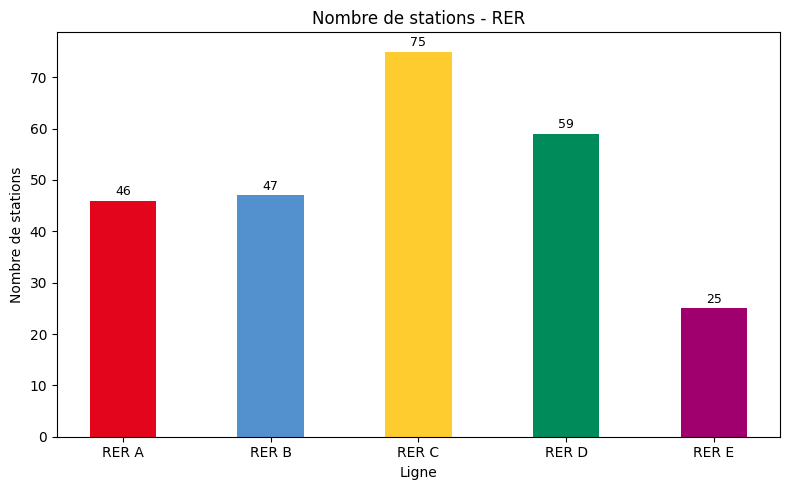

In [95]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Charger le fichier
# =========================
gares = pd.read_csv(
    "emplacement-des-gares-idf (1).csv",
    sep=";",
    encoding="utf-8-sig",
    low_memory=False
)

gares.columns = gares.columns.str.strip()

# Nettoyage colonnes utiles
gares["mode"] = gares["mode"].astype(str).str.strip().str.upper()
gares["res_com"] = gares["res_com"].astype(str).str.strip().str.upper()
gares["indice_lig"] = gares["indice_lig"].astype(str).str.strip().str.upper()
gares["gares_id"] = gares["gares_id"].astype(str).str.strip()

# Garder seulement RER et TRAIN
gares = gares[gares["mode"].isin(["RER", "TRAIN"])].copy()

# =========================
# 2. Construire la ligne
# =========================
def normaliser_ligne(row):
    mode = row["mode"]
    res = row["res_com"]
    ind = row["indice_lig"]

    if mode == "RER":
        for lettre in ["A", "B", "C", "D", "E"]:
            if ind == lettre or f"RER {lettre}" in res:
                return f"RER {lettre}"

    if mode == "TRAIN":
        for lettre in ["H", "J", "K", "L", "N", "P", "R", "U", "V"]:
            if ind == lettre:
                return lettre

    return None

gares["ligne"] = gares.apply(normaliser_ligne, axis=1)

# Diagnostic
print("Lignes détectées :")
print(sorted(gares["ligne"].dropna().unique()))

print("\nValeurs TRAIN par indice_lig :")
print(sorted(gares.loc[gares["mode"] == "TRAIN", "indice_lig"].dropna().unique()))

# Supprimer lignes non reconnues
gares = gares[gares["ligne"].notna()].copy()

# =========================
# 3. Couleurs officielles
# =========================
couleurs_lignes = {
    "RER A": "#E3051C",
    "RER B": "#5291CE",
    "RER C": "#FFCC30",
    "RER D": "#008B5B",
    "RER E": "#A0006E",
    "H": "#8D5E2A",
    "J": "#D4A017",
    "K": "#4B5320",
    "L": "#C9A3C9",
    "N": "#00A88F",
    "P": "#F28E00",
    "R": "#F4A6B8",
    "U": "#A50034",
    "V": "#6DA544"
}

# =========================
# 4. Compter les gares uniques
# =========================
nb_stations = (
    gares.groupby(["mode", "ligne"])["gares_id"]
    .nunique()
    .reset_index(name="nb_stations")
)

nb_stations["couleur"] = nb_stations["ligne"].map(couleurs_lignes).fillna("#999999")

# =========================
# 5. Séparer RER / Transilien
# =========================
ordre_rer = ["RER A", "RER B", "RER C", "RER D", "RER E"]
ordre_transilien = ["H", "J", "K", "L", "N", "P", "R", "U", "V"]

df_rer = nb_stations[nb_stations["mode"] == "RER"].copy()
df_transilien = nb_stations[nb_stations["mode"] == "TRAIN"].copy()

df_rer["ligne"] = pd.Categorical(df_rer["ligne"], categories=ordre_rer, ordered=True)
df_rer = df_rer.sort_values("ligne")

df_transilien["ligne"] = pd.Categorical(df_transilien["ligne"], categories=ordre_transilien, ordered=True)
df_transilien = df_transilien.sort_values("ligne")

# =========================
# 6. Graphique RER
# =========================
plt.figure(figsize=(8, 5))
plt.bar(
    df_rer["ligne"].astype(str),
    df_rer["nb_stations"],
    color=df_rer["couleur"],
    width=0.45
)
plt.title("Nombre de stations - RER")
plt.xlabel("Ligne")
plt.ylabel("Nombre de stations")

for i, v in enumerate(df_rer["nb_stations"]):
    plt.text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()



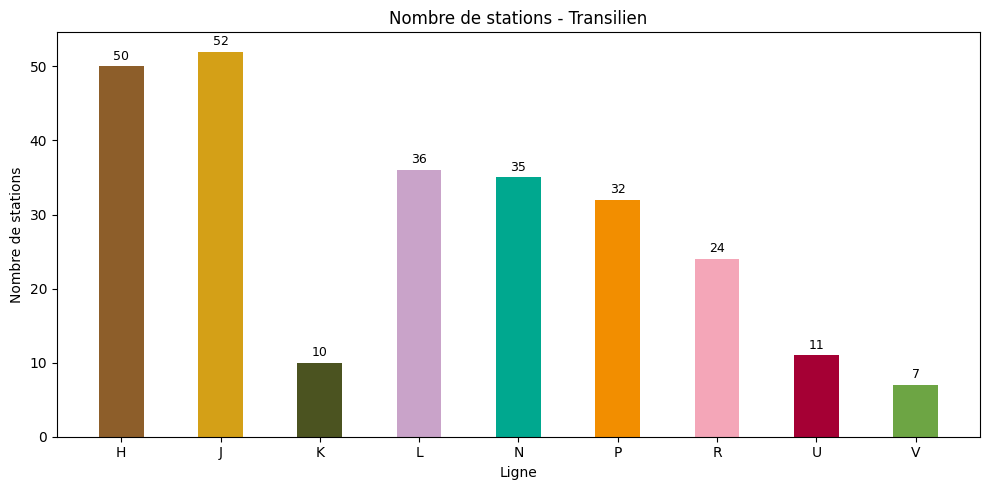


===== RER =====
   ligne  nb_stations
0  RER A           46
1  RER B           47
2  RER C           75
3  RER D           59
4  RER E           25

===== Transilien =====
   ligne  nb_stations
5      H           50
6      J           52
7      K           10
8      L           36
9      N           35
10     P           32
11     R           24
12     U           11
13     V            7


In [94]:
# =========================
# 7. Graphique Transilien
# =========================
plt.figure(figsize=(10, 5))
plt.bar(
    df_transilien["ligne"].astype(str),
    df_transilien["nb_stations"],
    color=df_transilien["couleur"],
    width=0.45
)
plt.title("Nombre de stations - Transilien")
plt.xlabel("Ligne")
plt.ylabel("Nombre de stations")

for i, v in enumerate(df_transilien["nb_stations"]):
    plt.text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

print("\n===== RER =====")
print(df_rer[["ligne", "nb_stations"]])

print("\n===== Transilien =====")
print(df_transilien[["ligne", "nb_stations"]])

In [88]:
df_transilien = nb_stations[nb_stations["ligne"].isin(transilien_lines)]